In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from pprint import pformat

from hloc import (
    extract_features,
    match_features,
    match_dense,
    pairs_from_covisibility,
    pairs_from_retrieval,
)
from hloc import colmap_from_nvm, triangulation, localize_sfm, visualization
import collections
import numpy as np
import pandas as pd

# Pipeline for UCF 3259 visual localization

In [2]:
dataset = Path("datasets/3259/")  # change this if your dataset is somewhere else
images = dataset / "video_frames/"
outputs = Path("outputs/3259/")  # where everything will be saved

# list the standard configurations available
print(f"Configs for feature extractors:\n{pformat(extract_features.confs)}")
print(f"Configs for feature matchers:\n{pformat(match_features.confs)}")
print(f"Configs for feature matchers:\n{pformat(match_dense.confs)}")

Configs for feature extractors:
{'aliked-n16': {'model': {'model_name': 'aliked-n16', 'name': 'aliked'},
                'output': 'feats-aliked-n16',
                'preprocessing': {'grayscale': False, 'resize_max': 1024}},
 'd2net-ss': {'model': {'multiscale': False, 'name': 'd2net'},
              'output': 'feats-d2net-ss',
              'preprocessing': {'grayscale': False, 'resize_max': 1600}},
 'dir': {'model': {'name': 'dir'},
         'output': 'global-feats-dir',
         'preprocessing': {'resize_max': 1024}},
 'disk': {'model': {'max_keypoints': 5000, 'name': 'disk'},
          'output': 'feats-disk',
          'preprocessing': {'grayscale': False, 'resize_max': 1600}},
 'disk2': {'model': {'max_keypoints': 4000, 'name': 'disk'},
           'output': 'feats-disk2',
           'preprocessing': {'grayscale': False, 'resize_max': 720}},
 'eigenplaces': {'model': {'name': 'eigenplaces'},
                 'output': 'global-feats-eigenplaces',
                 'preprocessing': 

In [3]:
# pick one of the configurations for image retrieval, local feature extraction, and matching
retrieval_conf = extract_features.confs["netvlad"]
feature_conf = extract_features.confs["superpoint_inloc"]
matcher_conf = match_features.confs["NN-superpoint"]
#feature_conf = extract_features.confs["sift"]
#matcher_conf = match_dense.confs['loftr_3259']

## Extract local features for database

In [100]:
# NOT FOR LOFTR
if matcher_conf["model"]["name"] != "loftr":
    features = extract_features.main(feature_conf, images, outputs)

[2025/01/04 17:29:39 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 4000, 'name': 'disk'},
 'output': 'feats-disk2',
 'preprocessing': {'grayscale': False, 'resize_max': 720}}
[2025/01/04 17:29:39 hloc INFO] Found 910 images in root datasets/3259/video_frames.
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 910/910 [00:34<00:00, 26.00it/s]
[2025/01/04 17:30:14 hloc INFO] Finished exporting features.


The function returns the path of the file in which all the extracted features are stored.

## Generate pairs for the SfM reconstruction
Instead of matching all database images exhaustively, we exploit the existing SIFT model to find which image pairs are the most covisible. We do a covisiblity search, selecting the top 20 most covisibile neighbors for each image.

In [5]:
sfm_pairs = outputs / "pairs-db-covis20.txt"  # top 20 most covisible in SIFT model
pairs_from_covisibility.main(outputs / "sfm_sift", sfm_pairs, num_matched=20)

[2025/01/04 16:55:55 hloc INFO] Reading the COLMAP model...
[2025/01/04 16:55:57 hloc INFO] Extracting image pairs from covisibility info...
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 910/910 [00:03<00:00, 297.32it/s]
[2025/01/04 16:56:00 hloc INFO] Found 18195 pairs.


## Match the database images

In [6]:
if matcher_conf["model"]["name"] != "loftr":
    sfm_matches = match_features.main(
        matcher_conf, sfm_pairs, feature_conf["output"], outputs
    )

[2025/01/04 16:56:00 hloc INFO] Matching local features with configuration:
{'model': {'distance_threshold': 0.7,
           'do_mutual_check': True,
           'name': 'nearest_neighbor'},
 'output': 'matches-NN-mutual-dist.7'}
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 11026/11026 [01:00<00:00, 183.72it/s]
[2025/01/04 16:57:00 hloc INFO] Finished exporting matches.


In [ ]:
# LOFTR
if matcher_conf["model"]["name"] == "loftr":
    features, sfm_matches = match_dense.main(
            matcher_conf, sfm_pairs, images, outputs, max_kps=8192, overwrite=False
        )

## Triangulate a new SfM model from the given poses
We triangulate the sparse 3D pointcloud given the matches and the reference poses stored in the SIFT COLMAP model.

In [7]:
reference_sfm = outputs / "sfm_superpoint+NN"  # the SfM model we will build
reconstruction = triangulation.main(
    reference_sfm, outputs / "sfm_sift", images, sfm_pairs, features, sfm_matches
)

[2025/01/04 16:57:00 hloc INFO] Importing features into the database...
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 910/910 [00:00<00:00, 3893.88it/s]
[2025/01/04 16:57:00 hloc INFO] Importing matches into the database...
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 18195/18195 [00:03<00:00, 4772.74it/s]
[2025/01/04 16:57:05 hloc INFO] Performing geometric verification of the matches...
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 910/910 [00:28<00:00, 32.45it/s]
[2025/01/04 16:57:33 hloc INFO] mean/med/min/max valid matches 42.58/37.44/0.31/97.31%.
[2025/01/04 16:57:33 hloc INFO] Running 3D triangulation...
I20250104 16:57:33.310694 139650671116672 incremental_pipeline.cc:237] Loading database
I20250104 16:57:33.311193 139650671116672 database_cache.cc:66] Loading cameras..

## Find image pairs via image retrieval
We extract global descriptors with NetVLAD and find for each image the $k$ most similar ones. A larger $k$ improves the robustness of the localization for difficult queries but makes the matching more expensive. Using $k{=}10{-}20$ is generally a good tradeoff.

In [8]:
global_descriptors = extract_features.main(retrieval_conf, images, outputs)

[2025/01/04 16:57:55 hloc INFO] Extracting local features with configuration:
{'model': {'name': 'netvlad'},
 'output': 'global-feats-netvlad',
 'preprocessing': {'resize_max': 1024}}
[2025/01/04 16:57:55 hloc INFO] Found 910 images in root datasets/3259/video_frames.



HHHHHHHHHHH /home/shubham/.cache/torch/hub/netvlad/VGG16-NetVLAD-Pitts30K.mat


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 910/910 [00:49<00:00, 18.45it/s]
[2025/01/04 16:58:48 hloc INFO] Finished exporting features.


# Query Images

In [133]:
num_retrival=20
retrival = "netvlad"
query_set = 2
retrieval_conf = extract_features.confs[retrival]

query_images = dataset / f"query_{query_set}"
outputs_query = outputs / f"query_{query_set}"
loc_pairs = outputs / f"pairs-query_{query_set}-{retrival}{num_retrival}.txt"
global_descriptors = outputs / f"global-feats-{retrival}.h5"
query_descriptors = outputs_query / f"global-feats-{retrival}.h5"


In [134]:
# Superpoint+SuperGlue
feature_conf = extract_features.confs["superpoint_inloc"]
matcher_conf = match_features.confs["superglue"]
matcher_name = matcher_conf["output"]

reconstruction = outputs / "sfm_superpoint+superglue"
features = outputs / "feats-superpoint-n4096-r1600.h5"

results = outputs / f"3259_hloc_query{query_set}_disk+{matcher_name}_{retrival}{num_retrival}.txt"  # the result file

In [90]:
# Superpoint+NN
feature_conf = extract_features.confs["superpoint_inloc"]
matcher_conf = match_features.confs["NN-superpoint"]
matcher_name = matcher_conf["output"]

reconstruction = outputs / "sfm_superpoint+NN"
features = outputs / "feats-superpoint-n4096-r1600.h5"

results = outputs / f"3259_hloc_query{query_set}_superpoint+{matcher_name}_{retrival}{num_retrival}.txt"  # the result file

In [91]:
# Sift+NN
feature_conf = extract_features.confs["sift"]
matcher_conf = match_features.confs["NN-ratio"]
matcher_name = matcher_conf["output"]

reconstruction = outputs / "sfm_sift_2"
features = outputs / "feats-sift.h5"

results = outputs / f"3259_hloc_query{query_set}_sift+{matcher_name}_{retrival}{num_retrival}.txt"  # the result file

In [ ]:
# DISK+LightGlue
feature_conf = extract_features.confs["disk"]
matcher_conf = match_features.confs["disk+lightglue"]
matcher_name = matcher_conf["output"]

reconstruction = outputs / "sfm_disk+lightglue"
features = outputs / "feats-disk.h5"

results = outputs / f"3259_hloc_query{query_set}_disk+{matcher_name}_{retrival}{num_retrival}.txt"  # the result file

In [109]:
# DISK2+NN
feature_conf = extract_features.confs["disk2"]
matcher_conf = match_features.confs["NN-ratio"]
matcher_name = matcher_conf["output"]

reconstruction = outputs / "sfm_disk2+NN"
features = outputs / "feats-disk2.h5"

results = outputs / f"3259_hloc_query{query_set}_disk+{matcher_name}_{retrival}{num_retrival}.txt"  # the result file

In [ ]:
# LOFTR
matcher_conf = match_dense.confs['loftr_3259']
matcher_name = matcher_conf["output"]

reconstruction = outputs / "sfm_loftr"
features = outputs / f"feats_{matcher_name}.h5"

query_matches = outputs_query / f"matches-loftr_{loc_pairs.stem}.h5"
results = outputs / f"3259_hloc_loftr_{retrival}{num_retrival}.txt"

## Feature extraction Query

In [135]:
# NOT FOR LOFTR
if matcher_conf["model"]["name"] != "loftr":
    features_query = extract_features.main(feature_conf, query_images, outputs_query)
    print(features_query)

[2025/01/04 17:35:03 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 4096, 'name': 'superpoint', 'nms_radius': 4},
 'output': 'feats-superpoint-n4096-r1600',
 'preprocessing': {'grayscale': True, 'resize_max': 1600}}
[2025/01/04 17:35:03 hloc INFO] Found 127 images in root datasets/3259/query_2.


Loaded SuperPoint model


/home/shubham/Downloads/unknot_codebase/Hierarchical-Localization/hloc/extractors/../../third_party/SuperGluePretrainedNetwork/models/superpoint.py:137: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to thi

outputs/3259/query_2/feats-superpoint-n4096-r1600.h5


In [136]:
query_descriptors = extract_features.main(retrieval_conf, query_images, outputs_query)
print(query_descriptors)

[2025/01/04 17:35:10 hloc INFO] Extracting local features with configuration:
{'model': {'name': 'netvlad'},
 'output': 'global-feats-netvlad',
 'preprocessing': {'resize_max': 1024}}
[2025/01/04 17:35:10 hloc INFO] Found 127 images in root datasets/3259/query_2.
[2025/01/04 17:35:10 hloc INFO] Skipping the extraction.


outputs/3259/query_2/global-feats-netvlad.h5


In [137]:
pairs_from_retrieval.main(
    query_descriptors, loc_pairs, num_matched=num_retrival, db_prefix=None,
    query_prefix=None, db_descriptors=global_descriptors
)

[2025/01/04 17:35:12 hloc INFO] Extracting image pairs from a retrieval database.
[2025/01/04 17:35:12 hloc INFO] Found 2540 pairs.


## Match the query images

In [138]:
# NOT FOR LOFTR
if matcher_conf["model"]["name"] != "loftr":
    query_matches = Path( outputs_query, f'{features_query.stem}_{matcher_conf["output"]}_{loc_pairs.stem}.h5') ## Match OUTPUT location
    loc_matches = match_features.main(
        matcher_conf, loc_pairs, features_query, outputs_query,
        query_matches, features_ref=features
    )

[2025/01/04 17:35:14 hloc INFO] Matching local features with configuration:
{'model': {'name': 'superglue',
           'sinkhorn_iterations': 50,
           'weights': 'outdoor'},
 'output': 'matches-superglue'}


outputs/3259/query_2/feats-superpoint-n4096-r1600.h5
Loaded SuperGlue model ("outdoor" weights)


/home/shubham/Downloads/unknot_codebase/Hierarchical-Localization/hloc/extractors/../../third_party/SuperGluePretrainedNetwork/models/superglue.py:226: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this

In [ ]:
# LOFTR
features_query, loc_matches = match_dense.main(
        matcher_conf,
        loc_pairs,
        dataset / "combined_with_query",
        outputs_query,
        max_kps=None,
        matches=query_matches,
        features_ref = features
    )

## Localize!

In [ ]:
# import h5py

# with h5py.File(features, 'r') as f:
#     # List all groups
#     data = f['1733767862507000064.jpg']['keypoints']
#     print(list(data)) 


In [139]:
localize_sfm.main(
    reconstruction,
    dataset / f"query_list_{query_set}_with_intrinsics.txt",
    loc_pairs,
    features_query,
    loc_matches,
    results,
    covisibility_clustering=False,
    inlier_threshold = 15,
)  # not required with SuperPoint+SuperGlue

[2025/01/04 17:41:30 hloc.utils.parsers INFO] Imported 127 images from query_list_2_with_intrinsics.txt
[2025/01/04 17:41:30 hloc INFO] Reading the 3D model...
[2025/01/04 17:41:30 hloc INFO] Starting localization...
  7%|████████                                                                                                          | 9/127 [00:00<00:06, 19.22it/s]

HERE >>>>>>>>UNABLE TO LOCALIZE: 1735845235175000064.jpg. inliers: 13 

HERE >>>>>>>>UNABLE TO LOCALIZE: 1735845238582000128.jpg. inliers: 14 



 14%|████████████████                                                                                                 | 18/127 [00:00<00:05, 19.34it/s]

HERE >>>>>>>>UNABLE TO LOCALIZE: 1735845252212000000.jpg. inliers: 7 



 31%|███████████████████████████████████▌                                                                             | 40/127 [00:02<00:03, 22.41it/s]

...

 76%|██████████████████████████████████████████████████████████████████████████████████████▎                          | 97/127 [00:04<00:01, 23.58it/s]

HERE >>>>>>>>UNABLE TO LOCALIZE: 1735845397022000128.jpg. inliers: 13 

HERE >>>>>>>>UNABLE TO LOCALIZE: 1735845400428999936.jpg. inliers: 9 

HERE >>>>>>>>UNABLE TO LOCALIZE: 1735845403836000000.jpg. inliers: 14 



 93%|████████████████████████████████████████████████████████████████████████████████████████████████████████        | 118/127 [00:06<00:00, 20.20it/s]

HERE >>>>>>>>UNABLE TO LOCALIZE: 1735845434502000128.jpg. inliers: 14 

HERE >>>>>>>>UNABLE TO LOCALIZE: 1735845436206000128.jpg. inliers: 11 

HERE >>>>>>>>UNABLE TO LOCALIZE: 1735845439612999936.jpg. inliers: 11 

HERE >>>>>>>>UNABLE TO LOCALIZE: 1735845443020000000.jpg. inliers: 8 



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 127/127 [00:06<00:00, 19.35it/s]
[2025/01/04 17:41:37 hloc INFO] Localized 106 / 127 images.
[2025/01/04 17:41:37 hloc INFO] Writing poses to outputs/3259/3259_hloc_query2_disk+matches-superglue_netvlad20.txt...
[2025/01/04 17:41:37 hloc INFO] Writing logs to outputs/3259/3259_hloc_query2_disk+matches-superglue_netvlad20.txt_logs.pkl...
[2025/01/04 17:41:37 hloc INFO] Done!


## Visualizing the SfM model
We visualize some of the database images with their detected keypoints.

Color the keypoints by track length: red keypoints are observed many times, blue keypoints few.

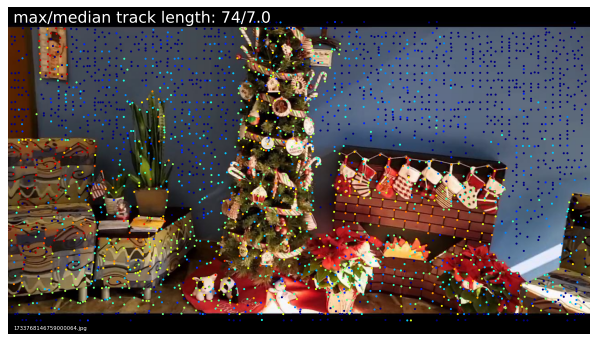

In [140]:
visualization.visualize_sfm_2d(reconstruction, images, n=1, color_by="track_length")

Color the keypoints by visibility: blue if sucessfully triangulated, red if never matched.

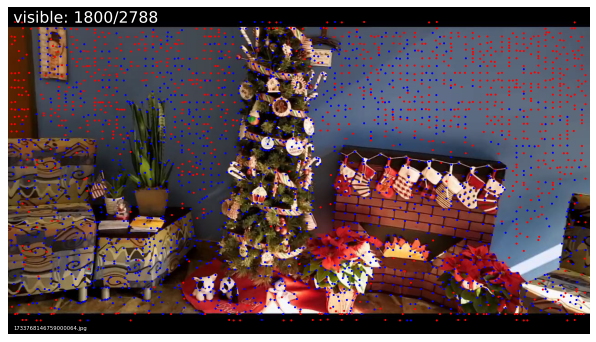

In [141]:
visualization.visualize_sfm_2d(reconstruction, images, n=1, color_by="visibility")

Color the keypoints by triangulated depth: red keypoints are far away, blue keypoints are closer.

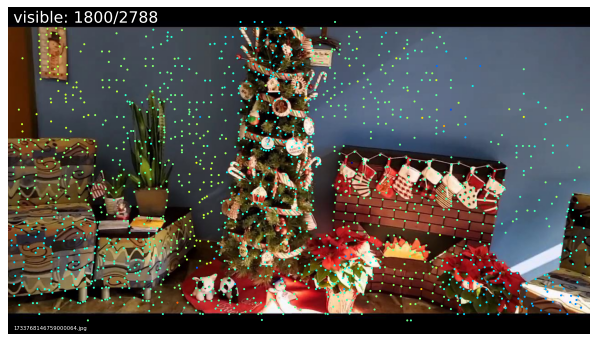

In [142]:
visualization.visualize_sfm_2d(reconstruction, images, n=1, color_by="depth")

## Visualizing the localization
We parse the localization logs and for each query image plot matches and inliers with a few database images.

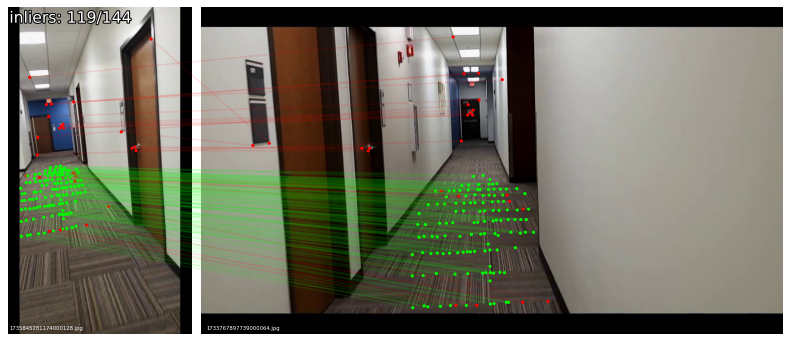

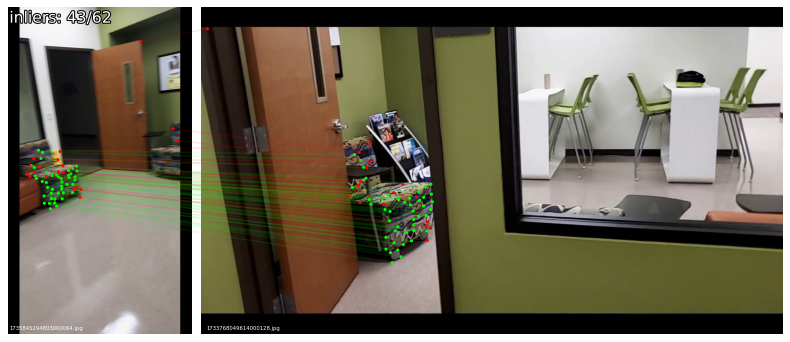

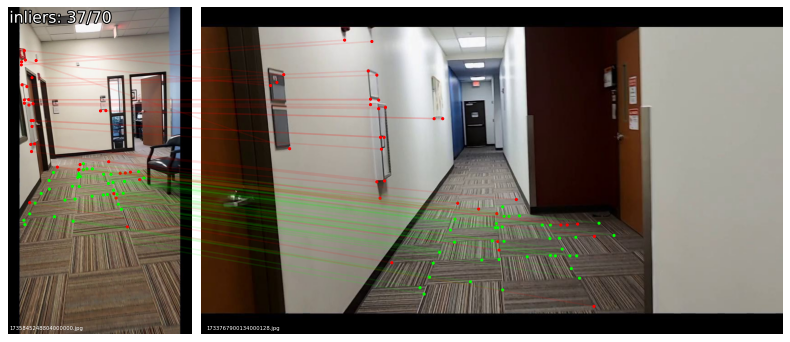

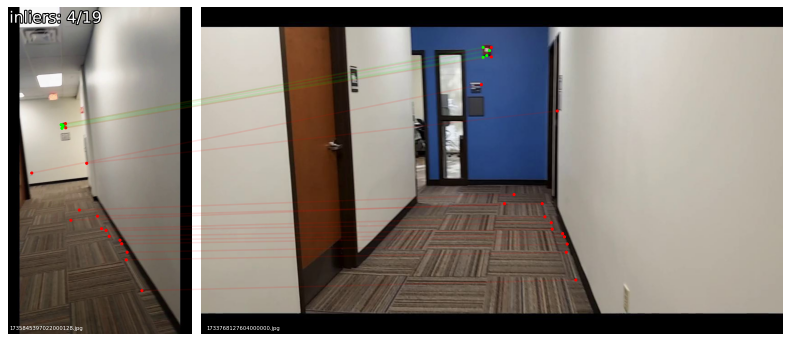

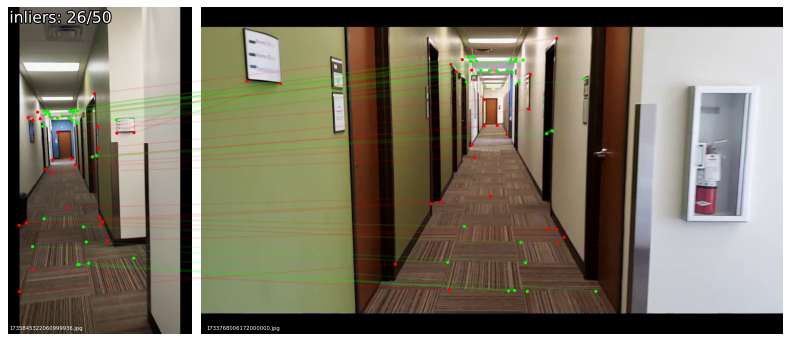

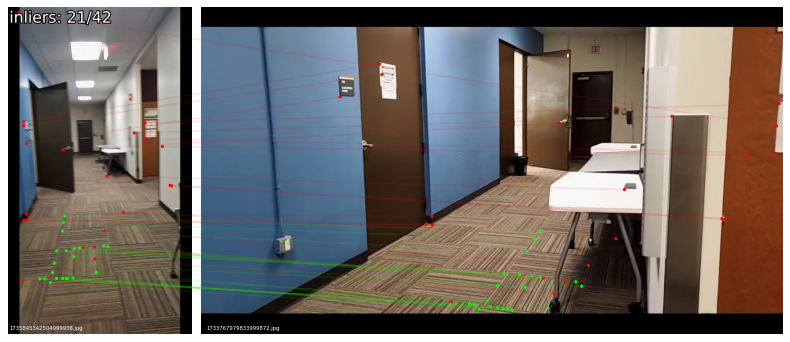

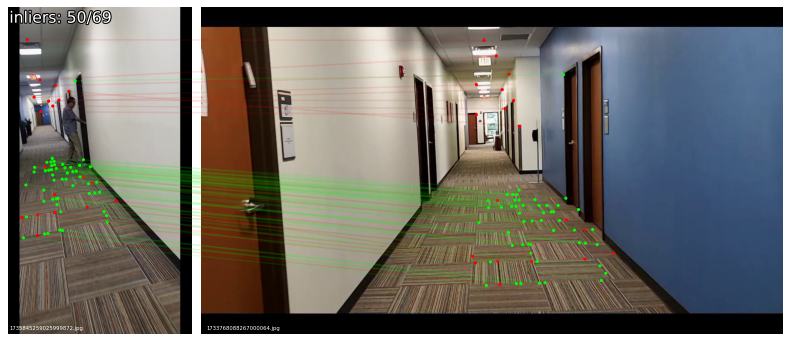

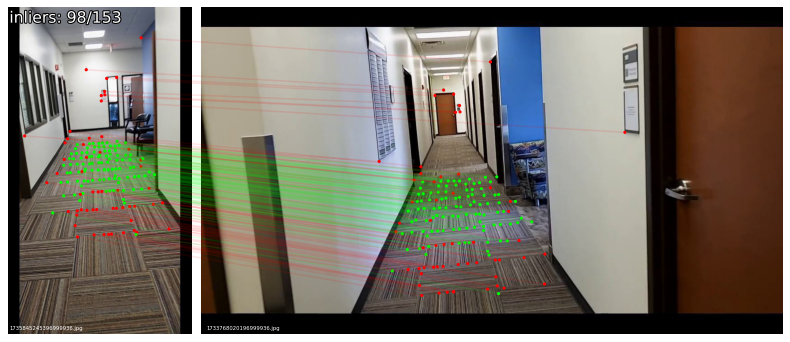

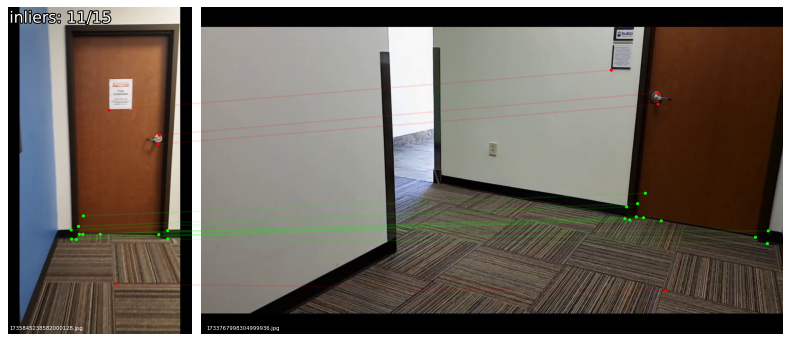

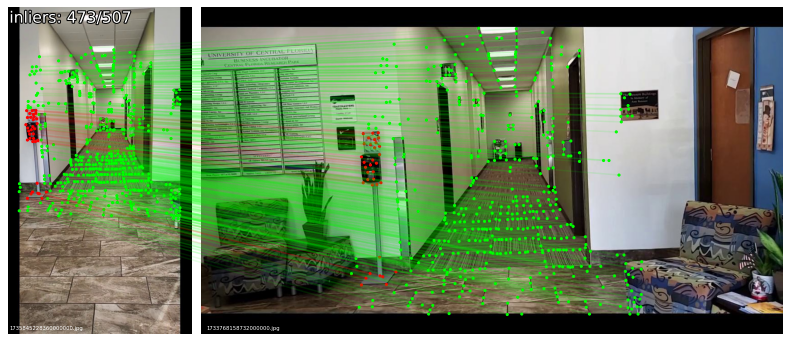

In [143]:
selected = []
visualization.visualize_loc(
    results, query_images, reconstruction, db_image_dir= images, selected = selected, n=10, top_k_db=1, prefix=None, seed=4
)

In [144]:
BaseImage = collections.namedtuple(
    "Image", ["qvec", "tvec", "name"]
)


class Image(BaseImage):
    def qvec2rotmat(self):
        return qvec2rotmat(self.qvec)


def qvec2rotmat(qvec: np.ndarray) -> np.ndarray:
    return np.array(
        [
            [
                1 - 2 * qvec[2] ** 2 - 2 * qvec[3] ** 2,
                2 * qvec[1] * qvec[2] - 2 * qvec[0] * qvec[3],
                2 * qvec[3] * qvec[1] + 2 * qvec[0] * qvec[2],
            ],
            [
                2 * qvec[1] * qvec[2] + 2 * qvec[0] * qvec[3],
                1 - 2 * qvec[1] ** 2 - 2 * qvec[3] ** 2,
                2 * qvec[2] * qvec[3] - 2 * qvec[0] * qvec[1],
            ],
            [
                2 * qvec[3] * qvec[1] - 2 * qvec[0] * qvec[2],
                2 * qvec[2] * qvec[3] + 2 * qvec[0] * qvec[1],
                1 - 2 * qvec[1] ** 2 - 2 * qvec[2] ** 2,
            ],
        ]
    )


def rotmat2qvec(R):
    Rxx, Ryx, Rzx, Rxy, Ryy, Rzy, Rxz, Ryz, Rzz = R.flat
    K = (
        np.array(
            [
                [Rxx - Ryy - Rzz, 0, 0, 0],
                [Ryx + Rxy, Ryy - Rxx - Rzz, 0, 0],
                [Rzx + Rxz, Rzy + Ryz, Rzz - Rxx - Ryy, 0],
                [Ryz - Rzy, Rzx - Rxz, Rxy - Ryx, Rxx + Ryy + Rzz],
            ]
        )
        / 3.0
    )
    eigvals, eigvecs = np.linalg.eigh(K)
    qvec = eigvecs[[3, 0, 1, 2], np.argmax(eigvals)]
    if qvec[0] < 0:
        qvec *= -1
    return qvec


def read_images_text(path: str) -> dict:
    images = {}
    with open(path, "r") as fid:
        while True:
            line = fid.readline()
            if not line:
                break
            line = line.strip()
            if len(line) > 0 and line[0] != "#":
                elems = line.split()
                qvec = np.array(tuple(map(float, elems[1:5])))
                tvec = np.array(tuple(map(float, elems[5:8])))
                image_name = elems[0]
                images[image_name] = Image(
                    qvec=qvec,
                    tvec=tvec,
                    name=image_name,
                )
    images = dict(sorted(images.items()))
    return images


def colmap_dict_to_pose(out_dict: dict):
    xyz = []
    quat = []
    stamps = np.array(list(out_dict.keys()))
    for img in out_dict.values():
        # rotation
        R = qvec2rotmat(img.qvec)
        # translation
        t = img.tvec
        # invert
        t = -R.T @ t
        q = rotmat2qvec(R.T)
        xyz.append(t)
        quat.append(q)
    xyz = np.vstack(xyz)  # [tx, ty, tz] n x 3
    quat = np.vstack(quat)  # [qw, qx, qy, qz] n x 4
    return stamps, xyz, quat

In [145]:
out_dict = read_images_text(results)
stamps, xyz, quat = colmap_dict_to_pose(out_dict)
df_pred = pd.DataFrame()
df_pred[["X", "Y", "Z"]] = xyz
df_pred["image_name"] = stamps
# stamps = stamps.reshape(-1, 1)
# final_out = np.hstack((xyz[:, 0:2], stamps))

In [146]:
gt_file = dataset / f"query_list_{query_set}_gt.txt"
df_gt = pd.read_csv(gt_file, sep=' ', header=None, names=['image_name', 'X', 'Y', 'Z'])

(np.float64(-567.2003965221844),
 np.float64(7358.739732816124),
 np.float64(-50.85111546867016),
 np.float64(1393.4185407976538))

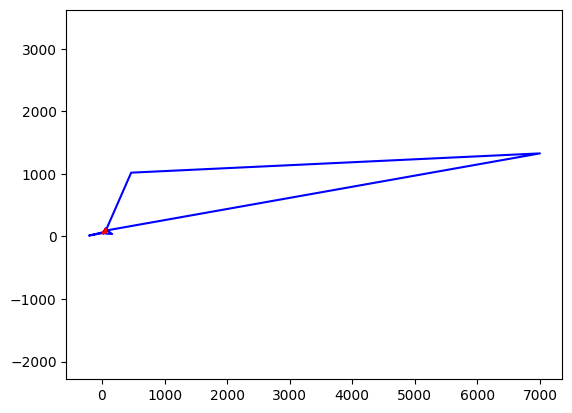

In [147]:
import matplotlib.pyplot as plt
plt.plot(df_pred["X"], df_pred["Y"], color ="blue")
plt.plot(df_gt["X"], df_gt["Y"], color ="red")
plt.axis('equal')

In [148]:
merged_df = pd.merge(df_pred, df_gt, on='image_name', how='inner', suffixes=('_pred', '_gt'))
del_x = merged_df['X_pred'] - merged_df['X_gt']
del_y = merged_df['Y_pred'] - merged_df['Y_gt']
error = del_x**2 + del_y**2
error = np.sqrt(error)

In [149]:
error[error > 5]


6     146.438521
7      72.864812
8      59.947070
9      56.785135
10     10.270853
         ...    
93     28.827917
94     20.806380
95    241.318048
96     34.635045
97      6.797387
Length: 80, dtype: float64

In [150]:
merged_df[error > 5]

,X_pred,Y_pred,Z_pred,image_name,X_gt,Y_gt,Z_gt
6,163.018811,38.798229,200.306095,1735845236879000064.jpg,17.524818,55.403611,1
7,50.669730,121.505229,1.095427,1735845241990000128.jpg,14.491943,58.256130,1
8,51.144454,107.687802,0.898390,1735845243692999936.jpg,14.486332,60.255394,1
9,51.222491,105.523466,0.793332,1735845245396999936.jpg,14.512068,62.200304,1
10,21.324602,71.851087,1.017392,1735845247100999936.jpg,14.563871,64.119145,1
...,...,...,...,...,...,...,...
93,62.320298,65.697656,0.851786,1735845429391000064.jpg,33.822500,61.347448,1
94,52.613608,62.602062,1.056200,1735845431095000064.jpg,31.854787,61.196072,1
95,-206.930391,14.797505,-14.886783,1735845432799000064.jpg,29.894030,61.150438,1
96,55.198774,76.507447,0.965769,1735845437908999936.jpg,24.060434,61.342022,1


In [151]:
selected = list(merged_df[error > 5]["image_name"])
print(selected)

['1735845236879000064.jpg', '1735845241990000128.jpg', '1735845243692999936.jpg', '1735845245396999936.jpg', '1735845247100999936.jpg', '1735845248804000000.jpg', '1735845250508000000.jpg', '1735845253915000064.jpg', '1735845255619000064.jpg', '1735845257323000064.jpg', '1735845259025999872.jpg', '1735845260729999872.jpg', '1735845262432999936.jpg', '1735845265840999936.jpg', '1735845267544000000.jpg', '1735845269248000000.jpg', '1735845270952000000.jpg', '1735845276063000064.jpg', '1735845277766000128.jpg', '1735845279470000128.jpg', '1735845281174000128.jpg', '1735845286284999936.jpg', '1735845293099000064.jpg', '1735845308432000000.jpg', '1735845310136000000.jpg', '1735845311839000064.jpg', '1735845313543000064.jpg', '1735845315247000064.jpg', '1735845316950000128.jpg', '1735845318654000128.jpg', '1735845320358000128.jpg', '1735845322060999936.jpg', '1735845323764999936.jpg', '1735845325468999936.jpg', '1735845327172000000.jpg', '1735845328876000000.jpg', '1735845330579000064.jpg', 

In [152]:
error.describe()

count     106.000000
mean       96.247405
std       688.417579
min         0.100326
25%         5.553496
50%        13.451699
75%        27.581187
max      7043.603110
dtype: float64

/home/shubham/Downloads/unknot_codebase/Hierarchical-Localization/hloc/utils/viz.py:41: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(


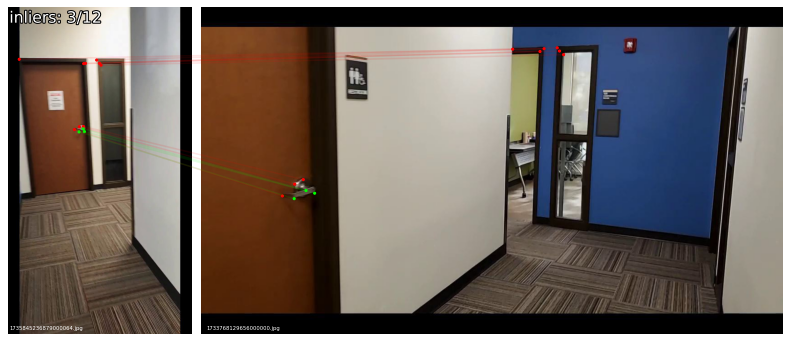

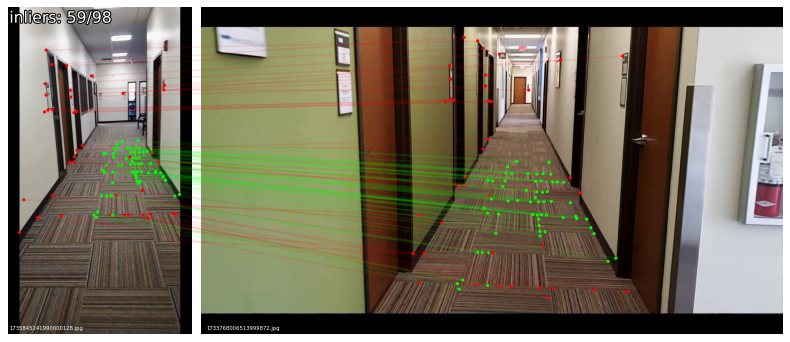

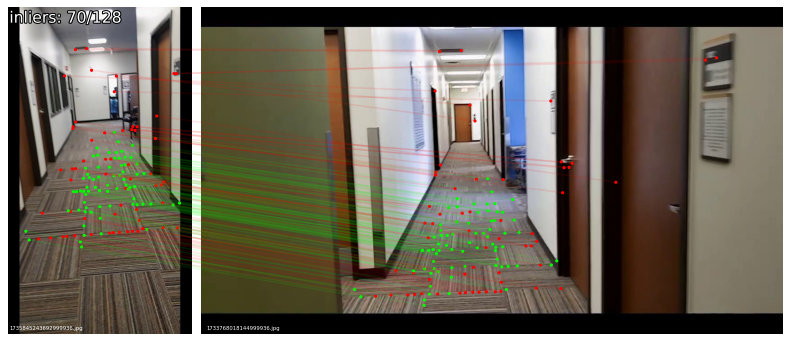

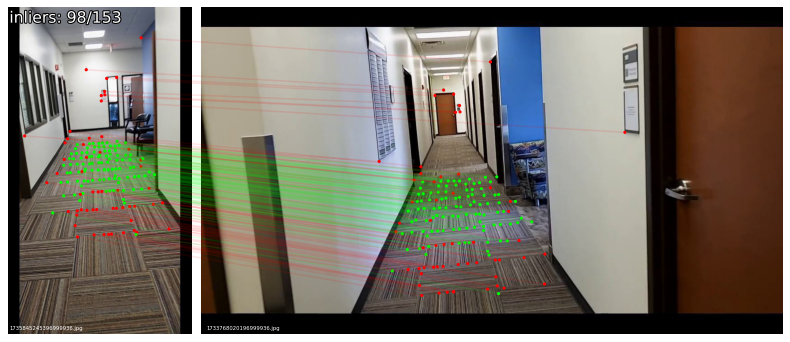

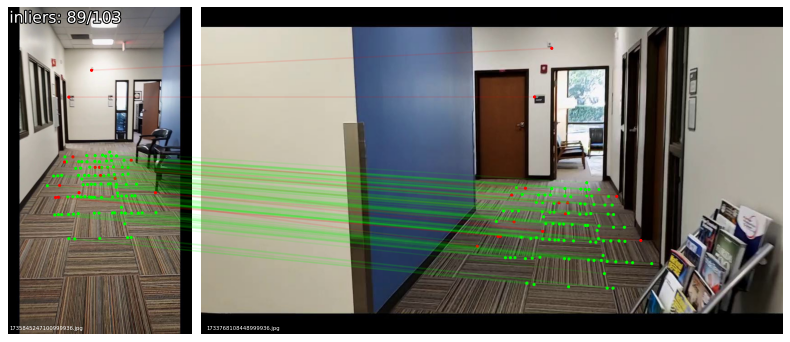

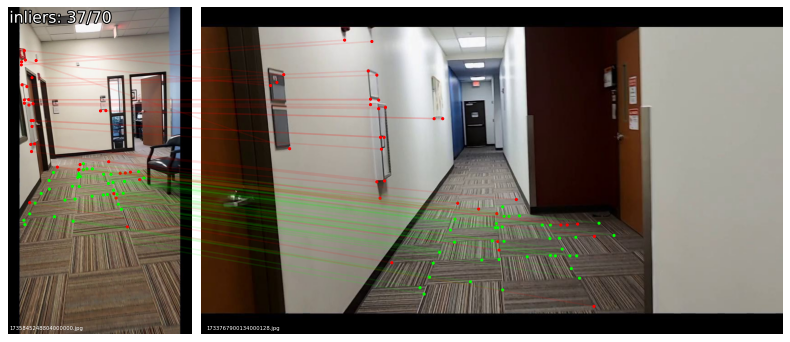

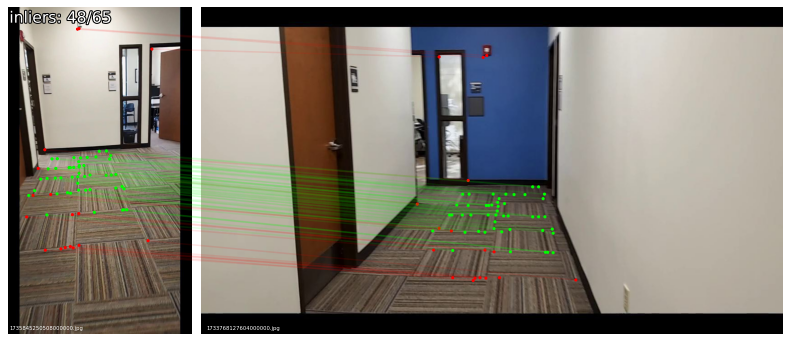

Error in callback <function flush_figures at 0x7f00c170df80> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [153]:
visualization.visualize_loc(
    results, query_images, reconstruction, db_image_dir= images, selected = selected, top_k_db=1, prefix=None, seed=4
)